In [9]:
using PyPlot
using ProgressBars
using JLD2
using Images, ImageFiltering
using Statistics

In [10]:
function smooth_imgs(img, size_kernel)
    flat_kernel = ones(size_kernel, size_kernel)/size_kernel^2
    img_smooth = imfilter(img, flat_kernel)
    return img_smooth
end

function normalize(img)
    img_norm = (img .- minimum(img)) ./ (maximum(img)-minimum(img))
    return img_norm
end

function find_droplets_radius_range(img, droplet_radius_range, threshold_droplets)
    blob_centers = []
    response = zeros(size(img))

    for droplet_radius in droplet_radius_range
        log_kernel = Kernel.gaussian(droplet_radius)
        response .+= imfilter(img, log_kernel)
        response = response .* droplet_radius^2
    end

    blobs = response .> threshold_droplets # Adaptative threshold depending on the std of the img

    label_blobs = label_components(blobs) # Separate the blobs
    for label in 1:maximum(label_blobs) # Find the center of each blob
        inds = findall(label_blobs .== label)
        push!(blob_centers, [mean([i[2]-1 for i in inds]), mean([i[1]-1 for i in inds])])
    end

    return blob_centers, label_blobs
end

find_droplets_radius_range (generic function with 1 method)

### Load the images/ODs

In [11]:
pathdir = "Y:/TwoDGas/2026/01/19/0046"
# pathdir = "Y:/TwoDGas/2025/07/04"

@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/ODs_crop_"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset

# Droplet parameters
size_kernel_smooth = 5
droplet_radius_range = [3:0.2:4;];

### Find the droplet thresholds

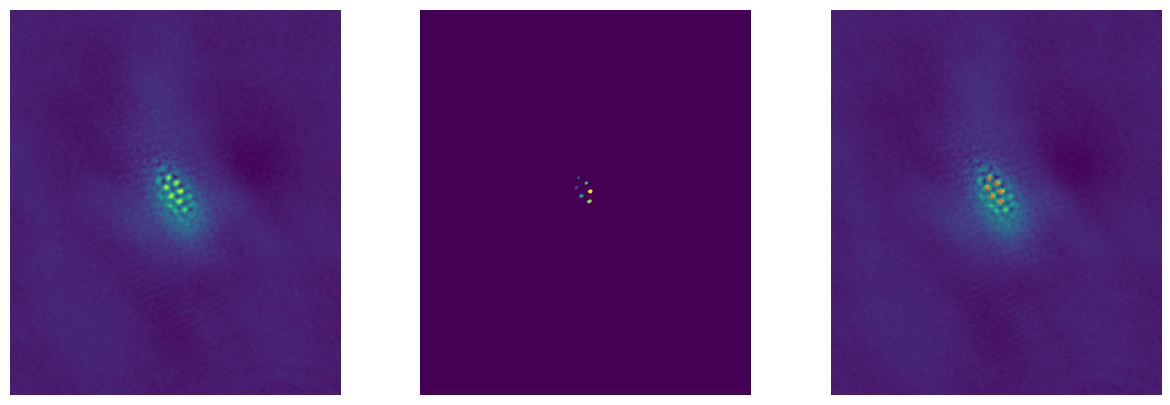

In [12]:
i, j = 6, 2
thresholds_droplets = [3000000, 2000000, 2500000, 2600000, 2700000, 2400000, 2300000, 2200000, 2300000, 2100000] # Y:/TwoDGas/2026/01/19/0046
# thresholds_droplets = [2300000, 2400000, 2700000, 2500000, 2400000, 2500000] # "Y:/TwoDGas/2025/07/04

close("all")
fig, axs = subplots(1, 3, figsize=(15, 5))

OD = ODs_dataset[i, j, :, :]

smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Normalize to gaussian kernel
centers, label_blobs = find_droplets_radius_range(smooth_norm_OD, droplet_radius_range, thresholds_droplets[i])

axs[1].imshow(smooth_norm_OD)

axs[2].imshow(label_blobs)

axs[3].imshow(smooth_norm_OD)
axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r", alpha=0.4)

for ax in axs
    ax.axis("off")
end

pygui(false);

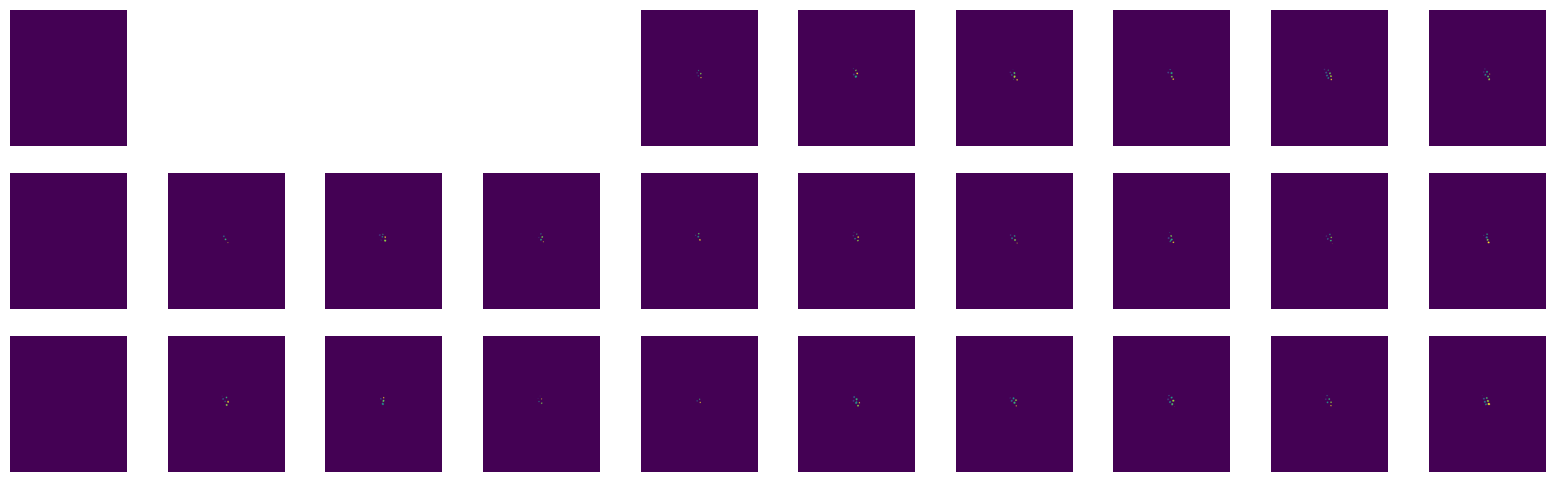

In [13]:
nbr_img_per_sat = 3

close("all")
fig, axs = subplots(nbr_img_per_sat, length(Sat), figsize=(2*length(Sat), 2*nbr_img_per_sat))

for i in 1:length(Sat)
    for j = 1:nbr_img_per_sat
        OD = ODs_dataset[i, j, :, :]
        smooth_OD = smooth_imgs(OD, size_kernel_smooth) # Normalize to gaussian kernel
        
        if maximum(smooth_OD)-minimum(smooth_OD) > 0.5 # Remove the shots gone wrong
            centers, label_blobs = find_droplets_radius_range(normalize(smooth_OD), droplet_radius_range, thresholds_droplets[i])

            axs[j, i].imshow(label_blobs)
        end

        for ax in axs
            ax.axis("off")
        end
    end
end

# axis("off")
pygui(false);

# Find the droplets

In [15]:
if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Droplets")
    mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Droplets")
end

"Images/2026_01_19_0046/Droplets"

In [17]:
nbr_droplets_ds = zeros(size(ODs_dataset)[1:2])
centers_droplets_ds = []
save_imgs = true

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

for i in ProgressBar(1:length(Sat))
    if !isdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Droplets/$(Sat[i])")
        mkdir("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Droplets/$(Sat[i])")
    end

    centers_droplets = []

    for j = 1:size(ODs_dataset)[2]
        OD = ODs_dataset[i, j, :, :]
        smooth_OD = smooth_imgs(OD, size_kernel_smooth) # Normalize to gaussian kernel

        if maximum(smooth_OD)-minimum(smooth_OD) > 0.5 # Remove the shots gone wrong
            smooth_norm_OD = normalize(smooth_OD)
            centers, label_blobs = find_droplets_radius_range(smooth_norm_OD, droplet_radius_range, thresholds_droplets[i])

            if save_imgs
                axs[1].imshow(smooth_norm_OD)
                axs[2].imshow(label_blobs)
                axs[3].imshow(OD)
                axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r", alpha=0.5)

                savefig("Images/"*join(split(pathdir, "/")[3:end], "_")*"/Droplets/$(Sat[i])/$(j-1).png")
                for ax in axs
                    ax.clear()
                end
            end

            nbr_droplets_ds[i, j] = length(centers)
        end
        push!(centers_droplets, centers)
    end
    push!(centers_droplets_ds, centers_droplets)
end

close("all")

0.0%┣                                               ┫ 0/10 [00:00<00:00, -0s/it]
10.0%┣████▏                                     ┫ 1/10 [00:05<Inf:Inf, InfGs/it]
20.0%┣█████████▍                                     ┫ 2/10 [00:09<01:09, 9s/it]
30.0%┣██████████████                                 ┫ 3/10 [00:12<00:43, 6s/it]
40.0%┣██████████████████▉                            ┫ 4/10 [00:16<00:32, 5s/it]
50.0%┣███████████████████████▌                       ┫ 5/10 [00:20<00:26, 5s/it]
60.0%┣████████████████████████████▏                  ┫ 6/10 [00:29<00:23, 6s/it]
70.0%┣█████████████████████████████████              ┫ 7/10 [00:35<00:17, 6s/it]
80.0%┣█████████████████████████████████████▋         ┫ 8/10 [00:40<00:11, 6s/it]
90.0%┣██████████████████████████████████████████▎    ┫ 9/10 [00:44<00:06, 6s/it]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:49<00:00, 5s/it]
100.0%┣█████████████████████████████████████████████┫ 10/10 [00:49<00:00, 5s/it]


In [18]:
@save "Saved_exp_data/Droplets_"*join(split(pathdir, "/")[3:end], "_")*".jld2" centers_droplets_ds nbr_droplets_ds